In [255]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Introdução
O dataset Pima Indians Diabetes Database, disponibilizado na plataforma Kaggle, é um dos conjuntos de dados mais clássicos e utilizados no cenário de Machine Learning para tarefas de classificação. Contudo, no presente trabalho, adotamos uma abordagem estatística ao aplicar o teste inferencial de Wilcoxon não pareado para uma amostra. O objetivo desta análise é compreender se os resultados dos exames dos pacientes saudáveis se distanciam ou não dos valores normais de referência na literatura médica.

"Definimos a H0 como: a mediana dos resultados de exames dos pacientes saudáveis é estatisticamente igual ao respectivo valor de referência médico, e a H1 como: a mediana difere significativamente do valor esperado. Com o teste sobre as hipóteses mostradas, podemos identificar quais exames são menos significativos no diagnóstico, visto que o grupo estudado é composto por pessoas comprovadamente saudáveis (esperando-se que não rejeitem a H0). Adicionalmente, para mensurar a força dessa distorção, utilizamos o coeficiente descritivo de tamanho de efeito r de Rosenthal para indicar a magnitude da diferença, enquanto a direção do afastamento (para mais ou para menos) é determinada pela análise comparativa direta entre a mediana observada e o valor de referência."

A escolha por esta base de dados para a aplicação do teste mencionado, justifica-se dado que as variáveis analisadas não seguem uma distribuição normal, como demonstramos pelo teste de shapiro wilk e por meio de algumas visualizações. Sendo assim os dados compreendem um cenário ideal para a aplicação do teste. Estruturalmente, o conjunto de dados é composto por resultados de exames clínicos, como Glicose e Pressão Arterial, além de fatores demográficos e históricos, como a idade da paciente e o número de gestações. Por fim, a variável alvo Outcome (Resultado) atua como o indicador binário que define a presença ou ausência do diagnóstico de diabetes.

Para nossa pesquisa selecionamos apenas os pacientes saudáveis (Outcome = 0) e descartamos as variaveis de idade e gestações, visto que para elas, não faria sentido comparar seus valores com uma referência, também não segmentamos os pacientes por idade sob a visão que 'teste uma amostra' não deveria englobar subgrupos. No mais, especificamente comparamos os valores observados com valores estáticos pois entendemos que o objetivo exigido do trabalho (dito: teste para uma amostra) não compreendia a comparação entre grupos, requerida explicitamente apenas para uma outra equipe.

A população Pima é conhecida por ter alta prevalência de obesidade e diabetes. Mesmo os "saudáveis" (Outcome=0) têm características diferentes da população geral. Se usarmos referências universais (OMS, etc.), é esperado que muitos rejeitem H0 não porque são doentes, mas porque a população baseline é diferente.
Isso é um problema metodológico real, mas não invalida o trabalho - desde que a interpretação seja ajustada.

## Descrição das variáveis

| Variável | Descrição |
|-----------|-----------|
| Pregnancies | Número de vezes que a paciente esteve grávida. |
| Glucose | Concentração de glicose plasmática após teste oral de tolerância à glicose (mg/dL). |
| BloodPressure | Pressão arterial diastólica (mmHg). |
| SkinThickness | Espessura da dobra cutânea do tríceps (mm). |
| Insulin | Nível de insulina sérica em 2 horas (µU/mL). |
| BMI | Índice de Massa Corporal (IMC), calculado como peso (kg) / altura² (m²). |
| DiabetesPedigreeFunction | Índice que estima a predisposição genética ao diabetes com base no histórico familiar. |
| Age | Idade da paciente (anos). |
| Outcome | Variável alvo: 1 indica presença de diabetes e 0 indica ausência de diabetes. |

| Variável      | μ₀ sugerido    | Justificativa                                              |
| ------------- | -------------- | ---------------------------------------------------------- |
| Glucose       | **105 mg/dL**  | Média U.S. Pima NGT (104,0) arredondada                    |
| BloodPressure | **70 mmHg**    | Mantido; alinhado à média populacional                     |
| SkinThickness | **28 mm**      | Centro da faixa "normal" do próprio dataset (20–40 mm)     |
| Insulin       | **64 µU/mL**   | Média geométrica U.S. Pima NGT                             |
| BMI           | **31,75 kg/m²** | Média do grupo saudável no dataset                         |

In [256]:
valores_referencia = {
    "Glucose": 105,
    "BloodPressure": 70,
    "SkinThickness": 28,
    "Insulin": 64,
    "BMI": 30.8,
}

In [257]:
df = pd.read_csv('diabetes.csv')

In [258]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [273]:
df.describe()

,Glucose,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction
count,262.000000,262.000000,262.000000,262.000000,262.000000
mean,111.431298,27.251908,130.854962,31.750763,0.472168
std,24.642133,10.434135,102.626177,6.794971,0.299240
min,56.000000,7.000000,15.000000,18.200000,0.085000
25%,94.000000,18.250000,66.000000,26.125000,0.261000
50%,107.500000,27.000000,105.000000,31.250000,0.413500
75%,126.000000,34.000000,163.750000,36.100000,0.624250
max,197.000000,60.000000,744.000000,57.300000,2.329000


In [259]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [260]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [261]:
df.duplicated().sum()

np.int64(0)

Nenhum valor nulo explicito ou duplicado

In [262]:
cols_com_zero_invalido = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

mask = (df[cols_com_zero_invalido] == 0).any(axis=1)

print(f"Linhas com valores inválidos: {mask.sum()}")
print(f"Linhas restantes: {(~mask).sum()}")

df = df[~mask]

Linhas com valores inválidos: 376
Linhas restantes: 392


Muitos valores para exames são iguais a zero, porém isso é biologicamente impossível, logo consideramos como dados faltantes e os removemos

In [263]:
df['Outcome'].value_counts()

Outcome
0    262
1    130
Name: count, dtype: int64

In [264]:
df[df['Age'] < 21].shape

(0, 9)

Nenhum paciente menor de 21 anos foi encontrado no dataset. Portanto, não há necessidade de filtrar os dados com base na idade. O filtro seria preciso pois os valores de referencia que adotamos são para adultos

Temos 262 saudáveis, os demais (130) são descartados da análise

In [265]:
df = df[df['Outcome'] == 0]
df.drop('Outcome', axis=1, inplace=True)
df.shape[0]

262

In [266]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000,262.000000
mean,2.721374,111.431298,68.969466,27.251908,130.854962,31.750763,0.472168,28.347328
std,2.617844,24.642133,11.892841,10.434135,102.626177,6.794971,0.299240,8.989008
min,0.000000,56.000000,24.000000,7.000000,15.000000,18.200000,0.085000,21.000000
25%,1.000000,94.000000,60.000000,18.250000,66.000000,26.125000,0.261000,22.000000
50%,2.000000,107.500000,70.000000,27.000000,105.000000,31.250000,0.413500,25.000000
75%,4.000000,126.000000,76.000000,34.000000,163.750000,36.100000,0.624250,30.000000
max,13.000000,197.000000,106.000000,60.000000,744.000000,57.300000,2.329000,81.000000


As colunas mencionadas também são removidas

In [267]:
df.drop('Pregnancies', axis=1, inplace=True)
df.drop('Age', axis=1, inplace=True)

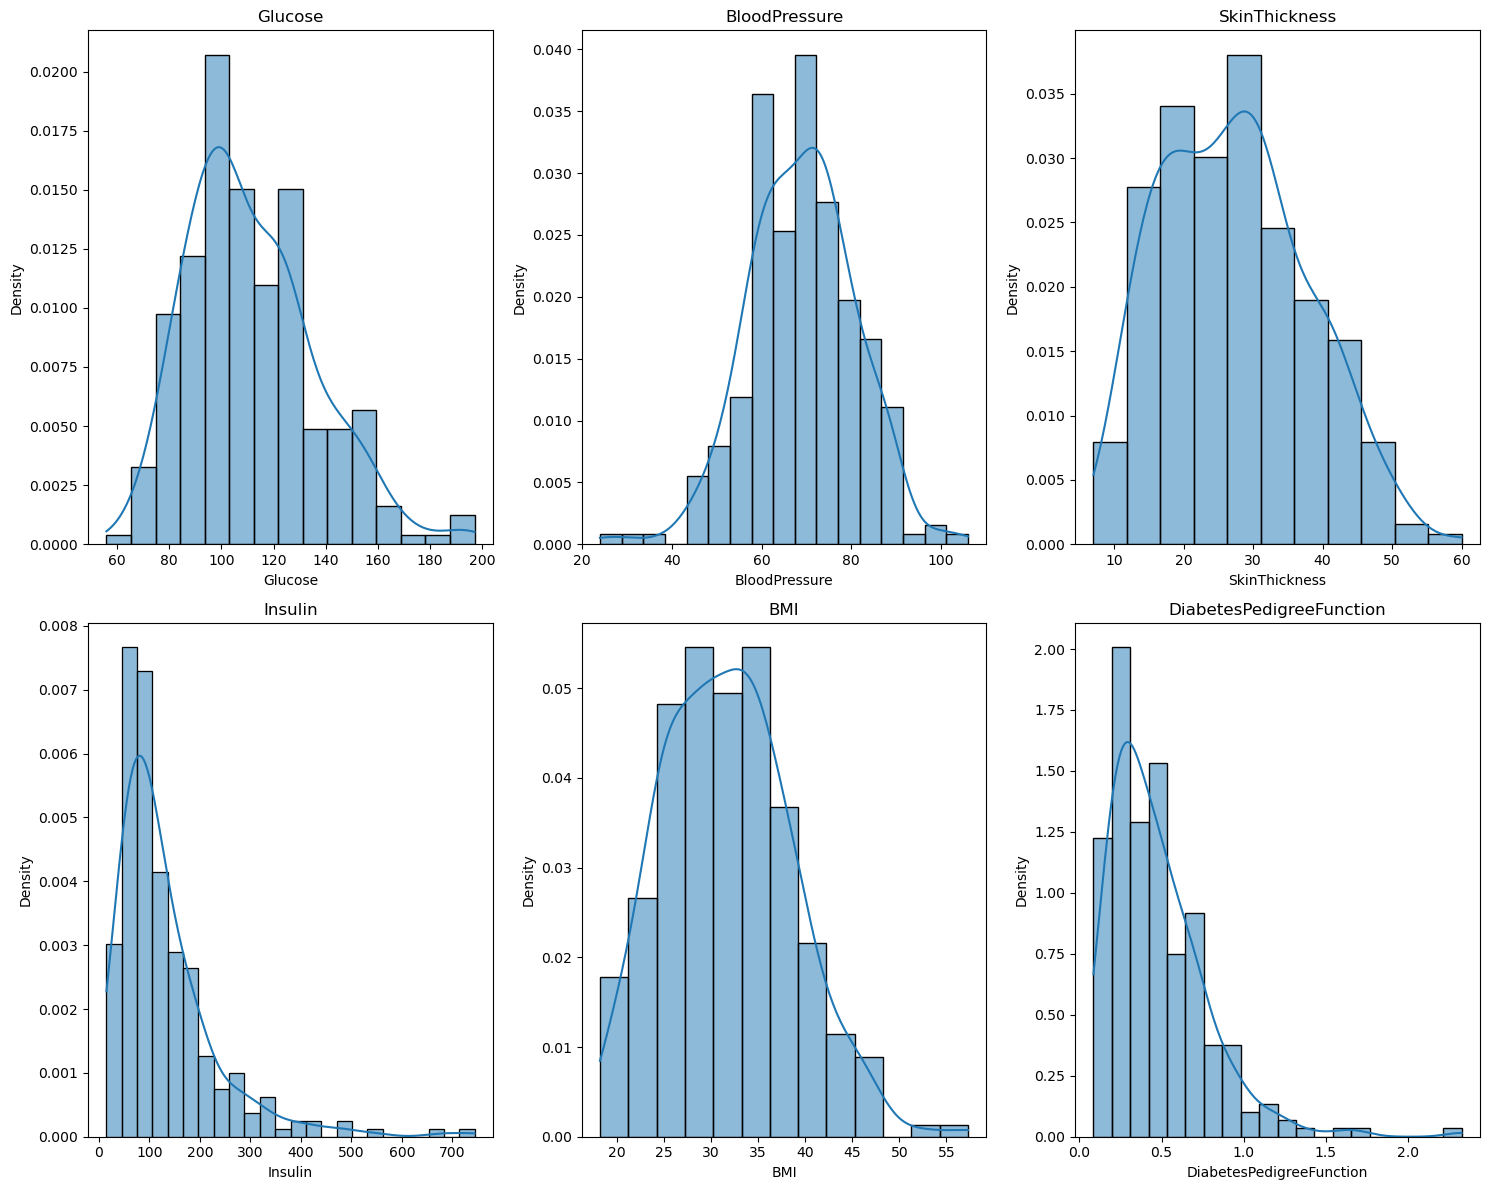

In [268]:
num_cols = df.select_dtypes(include='number')

fig, axes = plt.subplots(2, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        stat='density',
        common_norm=False,
        alpha=0.5,
        ax=axes[i]
    )
    axes[i].set_title(col)

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

A assimetria e caudas longas presentes nos gráficos já demonstra uma possivel não normalidade das distribuições, porém a análise visual ainda não é confiavel para estabelecer uma decisão. 

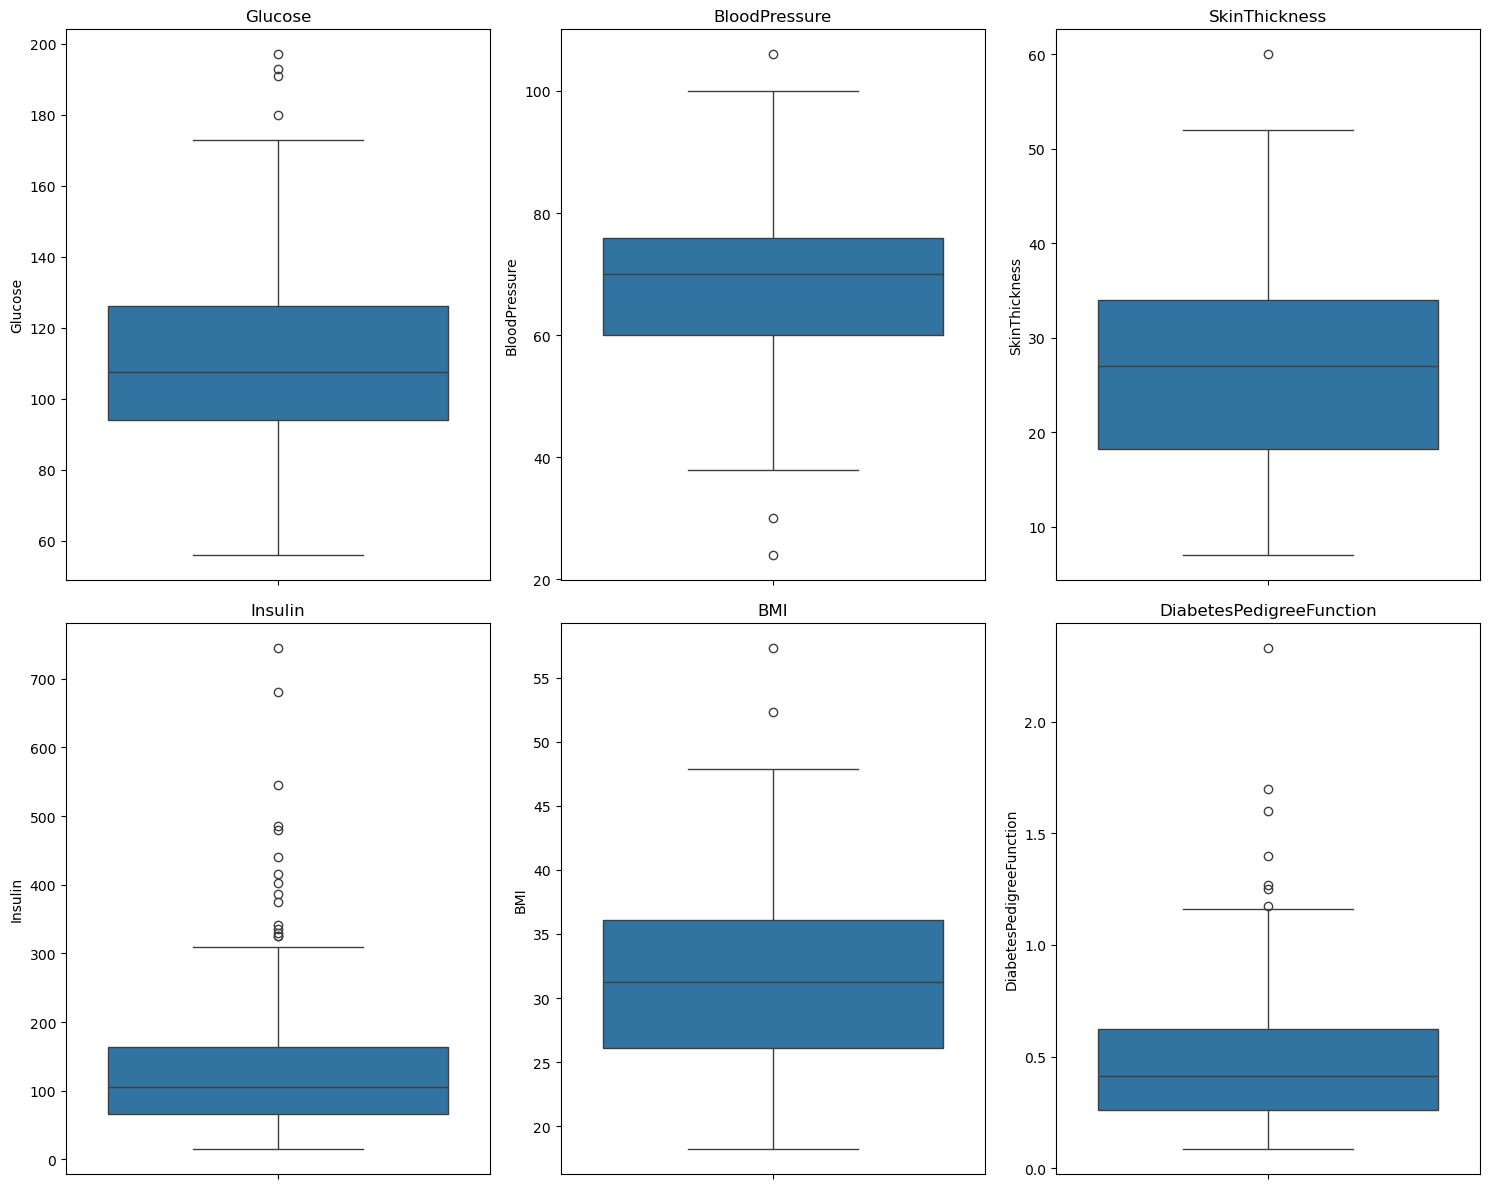

In [269]:
fig, axes = plt.subplots(2, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i]
    )
    axes[i].set_title(col)

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Notavelmente existem valores muito discrepantes dos intervalos interquatilicos aceitaveis, principalmente para a variável *Insulin* e *DiabetesPedigreeFunction*, o que pode apenas levantar uma indicação de que mesmo com valores extremos, por si proprias essas variaveis não atestam a doença.

In [270]:
from scipy.stats import shapiro

resultados = []

for col in num_cols:
    dados = df[col]

    stat, pvalue = shapiro(dados)

    resultados.append({
        'Variavel': col,
        'Estatística': round(stat, 4),
        'p-valor': pvalue,
        'Normal? (α=0.05)': 'Sim' if pvalue > 0.05 else 'Não',
        'Normal? (α=0.01)': 'Sim' if pvalue > 0.01 else 'Não'
    })

resultado_df = pd.DataFrame(resultados)

resultado_df

,Variavel,Estatística,p-valor,Normal? (α=0.05),Normal? (α=0.01)
0,Glucose,0.9657,6.463687e-06,Não,Não
1,BloodPressure,0.9901,7.293802e-02,Sim,Sim
2,SkinThickness,0.9783,4.914065e-04,Não,Não
3,Insulin,0.7706,7.450082e-19,Não,Não
4,BMI,0.9838,4.444661e-03,Não,Não
5,DiabetesPedigreeFunction,0.8641,1.883310e-14,Não,Não


Apenas BloodPressure demonstrou normalidade perante o teste, logo a descartamos ela já que não faria sentido aplicar wilcoxon para dados normais.

In [271]:
df = df.drop(columns=['BloodPressure'], axis=1)

In [272]:
import pandas as pd
import numpy as np

from scipy.stats import wilcoxon


def rosenthal_r(z, n):
    return z / np.sqrt(n)

def rosenthal_label(r):
    abs_r = abs(r)

    if abs_r < 0.10:
        stars = ""
    elif abs_r < 0.30:
        stars = "*"
    elif abs_r < 0.50:
        stars = "**"
    else:
        stars = "***"

    sinal = "+" if r >= 0 else "-"

    return f"({sinal}){stars}"


num_cols = [
    c for c in valores_referencia.keys()
    if c in df.columns
]


resultados_wilcoxon = []

for col in num_cols:

    dados = df[col].dropna()

    referencia = valores_referencia[col]

    diferencas = dados - referencia

    # Wilcoxon Signed-Rank
    stat, pvalue = wilcoxon(
        diferencas,
        alternative="two-sided",
        zero_method="wilcox"
    )

    n = len(diferencas)

    # Aproximação normal do Z
    media_w = n * (n + 1) / 4
    sd_w = np.sqrt(n * (n + 1) * (2 * n + 1) / 24)

    z = (stat - media_w) / sd_w

    # Rosenthal r
    r = rosenthal_r(z, n)

    resultados_wilcoxon.append({
        "Variavel": col,
        "Mediana Observada": round(dados.median(), 4),
        "Mediana Referência": referencia,
        "r": rosenthal_label(r),
        "W": round(stat, 4),
        "Z": round(z, 4),
        "p-valor": round(pvalue, 6),
        "α=0.01": "Rejeita H₀" if pvalue < 0.01 else "Não Rejeita H₀",
        "α=0.05": "Rejeita H₀" if pvalue < 0.05 else "Não Rejeita H₀",
        "α=0.10": "Rejeita H₀" if pvalue < 0.10 else "Não Rejeita H₀",
    })

df_resultados_wilcoxon = pd.DataFrame(resultados_wilcoxon)
df_resultados_wilcoxon.index = df_resultados_wilcoxon.pop("Variavel")

df_resultados_wilcoxon

,Mediana Observada,Mediana Referência,r,W,Z,p-valor,α=0.01,α=0.05,α=0.10
Variavel,,,,,,,,,
Glucose,107.50,105.0,(-)*,12896.5,-3.5268,0.001498,Rejeita H₀,Rejeita H₀,Rejeita H₀
SkinThickness,27.00,28.0,(-)*,14329.5,-2.3596,0.136064,Não Rejeita H₀,Não Rejeita H₀,Não Rejeita H₀
Insulin,105.00,64.0,(-)***,3836.0,-10.9067,0.000000,Rejeita H₀,Rejeita H₀,Rejeita H₀
BMI,31.25,30.8,(-)*,14540.5,-2.1878,0.087838,Não Rejeita H₀,Não Rejeita H₀,Rejeita H₀
